# Import libraries

In [146]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
# load dataset 
df = pd.read_csv('indian_pharmaceutical_products_clean-selected-columns.csv')

# EDA

In [148]:
df.describe() 

,product_id,price_inr,pack_size,num_active_ingredients
count,253973.000000,253973.000000,231643.000000,253973.000000
mean,126987.000000,270.530844,18.988871,1.441893
std,73315.834296,3029.584134,36.717320,0.496795
min,1.000000,0.000000,1.000000,1.000000
25%,63494.000000,48.000000,10.000000,1.000000
50%,126987.000000,79.000000,10.000000,1.000000
75%,190480.000000,140.000000,10.000000,2.000000
max,253973.000000,436000.000000,5000.000000,5.000000


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  object 
 2   manufacturer            253973 non-null  object 
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  object 
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  object 
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 17.7+ MB


In [150]:
df.shape

(253973, 10)

In [151]:
df.sample(5) 

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
177982,177983,Picgo 5mg Oral Solution,Aingo Pharma Pvt Ltd,74.5,False,solution,100.0,bottle,1,Sodium Picosulfate
206378,206379,Sunmox CV Dry Syrup,Aelida Healthcare,55.0,False,syrup,30.0,bottle,2,Amoxycillin
84054,84055,Femilon Tablet,Organon (India) Ltd,300.0,False,tablet,21.0,strip,2,Ethinyl Estradiol
188770,188771,Rosu F 145mg/10mg Tablet,Davaindia Generic Pharmacy,31.0,False,tablet,10.0,strip,2,Fenofibrate
253185,253186,Zenidime 1000mg Injection,Zenicure Labs,240.0,False,injection,NaN,NaN,1,Ceftazidime


In [152]:
# Check missing val

df.isnull().sum()

product_id                    0
brand_name                    0
manufacturer                  0
price_inr                     0
is_discontinued               0
dosage_form                   0
pack_size                 22330
pack_unit                 22330
num_active_ingredients        0
primary_ingredient            0
dtype: int64

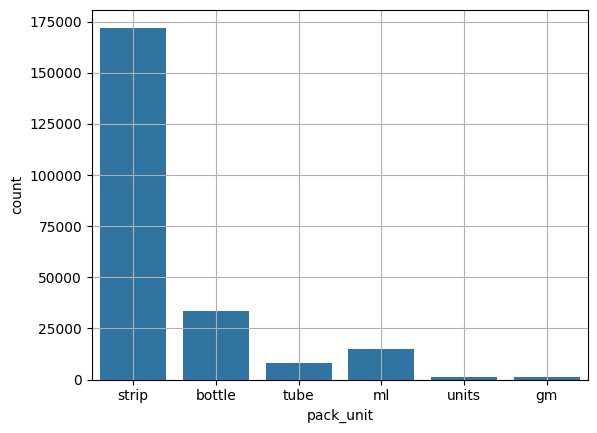

In [153]:
sns.countplot(x = df['pack_unit']) 
plt.grid()

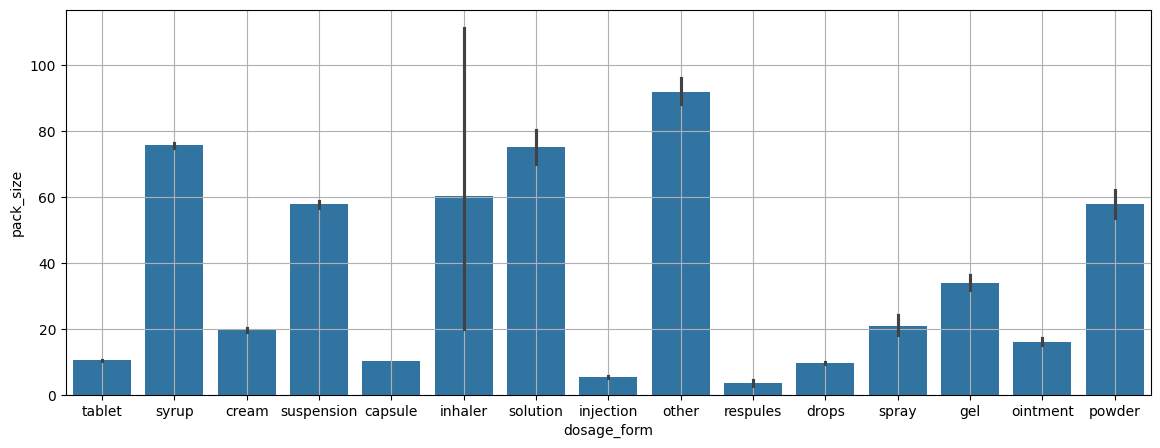

In [154]:
fig, ax = plt.subplots(1,1, figsize = (14,5))  
sns.barplot(x = df['dosage_form'], y = df['pack_size'], ax= ax)
plt.grid() 

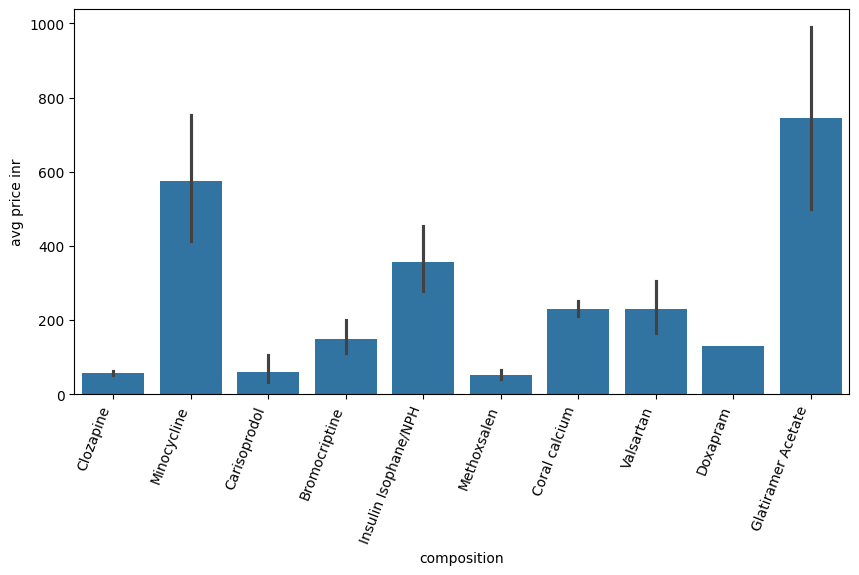

In [287]:
top_10_comps = df['primary_ingredient'].value_counts().sample(10).index

df_top_comps = df[df['primary_ingredient'].isin(top_10_comps)]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_comps, x='primary_ingredient', y='price_inr')
plt.xticks(rotation=69, ha='right') 
plt.ylabel('avg price inr')
plt.xlabel('composition')
plt.show() 

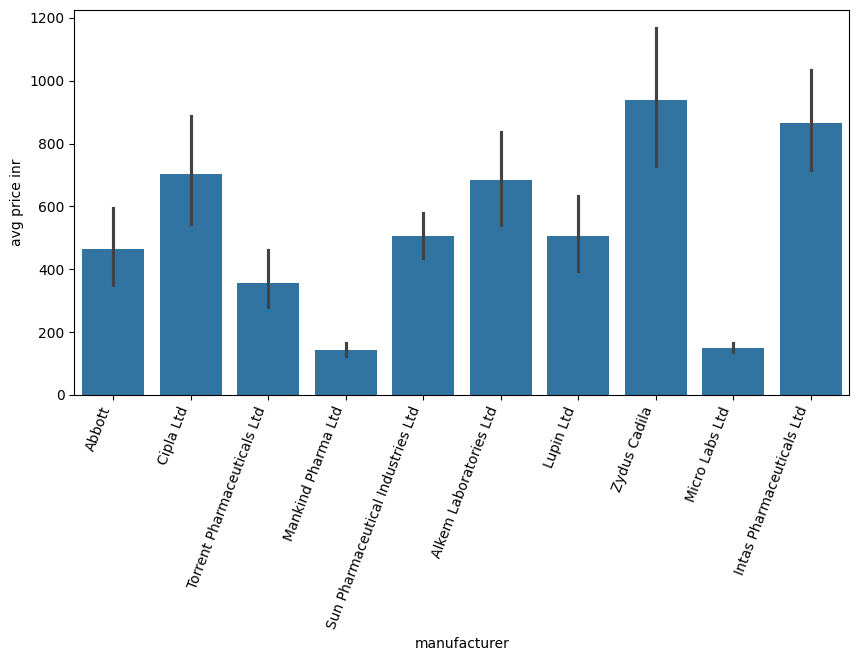

In [289]:
top_10_makers = df['manufacturer'].value_counts().head(10).index

df_top_makers = df[df['manufacturer'].isin(top_10_makers)]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_makers, x='manufacturer', y='price_inr')
plt.xticks(rotation=69, ha='right') 
plt.ylabel('avg price inr')
plt.xlabel('manufacturer')
plt.show()

In [ ]:
df[df['price_inr'] == 0.0]   

# All the medicines with price_inr = 0 are COVID-19 vaccines.

# So there are two possibilities:
# -> 0 means medicine was free 
# -> 0 means the price is unavailable or may be missing

# but model will not preform good when price is zero, so i decided to drop it 

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
35090,35091,Covishield Vaccine,Serum Institute Of India Ltd,0.0,False,injection,5.0,ml,1,ChAdOx1 nCoV-19 Corona Virus Vaccine
37004,37005,Covaxin Vaccine,Bharat Biotech,0.0,False,injection,10.0,ml,2,Whole Virion
141999,142000,Moderna Vaccine,"ModernaTX, Inc",0.0,False,injection,5.0,ml,1,Messenger ribonucleic acid
204460,204461,Sputnik V Vaccine,Dr Reddy's Laboratories Ltd,0.0,False,injection,5.0,ml,1,Human adenovirus vector vaccine


In [156]:
# pack_size                 22330 
# pack_unit                 22330 

df[df['pack_size'].isnull()].head()          

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
25,26,Asthalin 100mcg Inhaler,Cipla Ltd,157.85,False,inhaler,NaN,NaN,1,Salbutamol
39,40,Arachitol 6L Injection,Abbott,407.76,False,injection,NaN,NaN,1,Vitamin D3
53,54,Alex Cough Lozenges Lemon Ginger,Glenmark Pharmaceuticals Ltd,108.00,False,other,NaN,NaN,1,Dextromethorphan Hydrobromide
66,67,Akt 4 Kit,Lupin Ltd,24.70,False,other,NaN,NaN,2,Isoniazid
87,88,Aerocort Inhaler,Cipla Ltd,273.77,False,inhaler,NaN,NaN,2,Levosalbutamol


In [157]:
( df['pack_size'].isnull() == df['pack_unit'].isnull()).all()       # 'pack_size' and 'pack_unit' columns have missing values on the same row  

np.True_

In [158]:
df[df['pack_size'].isnull()]['dosage_form'].value_counts()

dosage_form
injection     19794
capsule        1131
other           707
inhaler         250
tablet          165
respules         89
spray            79
solution         48
drops            16
suspension       14
syrup            12
gel               8
powder            7
ointment          5
cream             5
Name: count, dtype: int64

In [159]:
print(df[['pack_size']].isnull().mean() * 100)     # drop the rows is not good valuable 
print(df[['pack_unit']].isnull().mean() * 100) 

pack_size    8.792273
dtype: float64
pack_unit    8.792273
dtype: float64


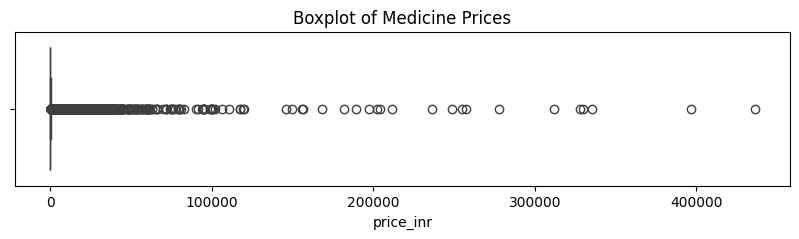

In [160]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df['price_inr'])
plt.title("Boxplot of Medicine Prices")
plt.show()

In [161]:
df['price_inr'].max()

np.float64(436000.0)

In [162]:
df['price_inr'].describe(percentiles=[.25, .5, .75, .90, .95, .99])   # i have to drop the rows having price value above 99%ile 

count    253973.000000
mean        270.530844
std        3029.584134
min           0.000000
25%          48.000000
50%          79.000000
75%         140.000000
90%         254.000000
95%         430.500000
99%        2899.280000
max      436000.000000
Name: price_inr, dtype: float64

# Data cleaning

In [163]:
df_ml = df.copy() 

In [164]:
df_ml.sample(5)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
206255,206256,Sifem 25mg Tablet,Dewcare Concept Pvt.Ltd.,32.0,False,tablet,10.0,strip,1,Clomiphene
93673,93674,Fradic 75mg Injection,Frank Medilink,21.0,False,injection,1.0,ml,1,Diclofenac
133885,133886,Misopt Eye Drop,Micro Labs Ltd,470.0,False,drops,5.0,ml,2,Dorzolamide
24828,24829,Agzitor TZ 1000mg/125mg Injection,Agrim Pharmaceuticals,152.0,False,injection,NaN,NaN,2,Ceftriaxone
92426,92427,Foxa OZ 200mg/500mg Tablet,SBS Biosciences,87.0,False,tablet,10.0,strip,2,Ofloxacin


In [165]:
df_ml = df_ml[df_ml['price_inr'] > 0]                 # 0 price not possibe there should a valid price of a medicine   
df_ml = df_ml[df_ml['price_inr'] <= 3000] 
 
# droping unused columns
X = df_ml.drop(columns=['price_inr', 'product_id', 'brand_name']) 
y = df_ml['price_inr']

# handle missing values 
X['pack_size'] = X['pack_size'].fillna(-1)
X['pack_unit'] = X['pack_unit'].fillna('Unknown')
X['is_discontinued'] = X['is_discontinued'].astype(int)

In [166]:
import re

def clean_composition_text(text):

    if pd.isna(text):
        return ""
    text = str(text).lower()
    
    text = re.sub(r'[()\[\]]', '', text)             # Remove brackets
    text = re.sub(r'[-_]', ' ', text)                # Replaces hyphens with space
    text = re.sub(r'\s*/\s*', ' / ', text)           # Standardize slashes
    text = re.sub(r'\s+', ' ', text).strip()         # Remove extra spaces

    return text

X['cleaned_composition'] = X['primary_ingredient'].apply(clean_composition_text)

In [167]:
# verify 

comparison = X[
    ['primary_ingredient', 'cleaned_composition']
]

comparison.sample(5)

,primary_ingredient,cleaned_composition
11382,Chlorpheniramine Maleate,chlorpheniramine maleate
236244,Betahistine,betahistine
163679,Metformin,metformin
117549,Itraconazole,itraconazole
65310,Montelukast,montelukast


In [168]:
print(X['primary_ingredient'].nunique())
print(X['cleaned_composition'].nunique())

1457
1456


In [169]:
X.drop(columns = ['primary_ingredient'],inplace = True)     

In [170]:
X

,manufacturer,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,cleaned_composition
0,Glaxo SmithKline Pharmaceuticals Ltd,0,tablet,10.0,strip,2,amoxycillin
1,Alembic Pharmaceuticals Ltd,0,tablet,5.0,strip,1,azithromycin
2,Glenmark Pharmaceuticals Ltd,0,syrup,100.0,bottle,2,ambroxol
3,Sanofi India Ltd,0,tablet,10.0,strip,1,fexofenadine
4,Sanofi India Ltd,0,tablet,15.0,strip,1,pheniramine
...,...,...,...,...,...,...,...
253968,Ziyana Lifesciences Pvt Ltd,0,suspension,30.0,bottle,1,cefpodoxime proxetil
253969,Leeford Healthcare Ltd,0,tablet,10.0,strip,1,diltiazem
253970,Euro Organics,0,tablet,10.0,strip,1,hydroxyzine
253971,Burgeon Health Series Private Limited,0,injection,-1.0,Unknown,1,azithromycin


# Preprocessing

In [171]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder 
from sklearn.compose import ColumnTransformer  
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

In [172]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 'manufacturer', 'cleaned_composition', 'dosage_form', 'pack_unit'

In [173]:
# define columntransformer
trf = ColumnTransformer(
    transformers=[
        
        ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['dosage_form', 'pack_unit']),
        
        ('tar_enc', TargetEncoder(target_type='continuous', smooth="auto"), ['manufacturer', 'cleaned_composition'])
    ], 
    remainder='passthrough'
)

trf.set_output(transform="pandas")

X_train_trf = trf.fit_transform(X_train, y_train)
X_test_trf = trf.transform(X_test)

In [174]:
# transform y for model training using PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
y_train_transformed = pt.fit_transform(y_train.values.reshape(-1, 1)).ravel() 

In [175]:
# train randomforest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_trf, y_train_transformed)

# model evaluation 
y_pred_transformed_rf = model_rf.predict(X_test_trf)

# convert predictions into inr
y_pred_rupees_rf = pt.inverse_transform(y_pred_transformed_rf.reshape(-1, 1))  

#  MAE in inr
mae_rupees = mean_absolute_error(y_test, y_pred_rupees_rf)
print(f" MAE in rupee: {mae_rupees:.2f}")

 MAE in rupee: 49.96


In [176]:
# train HistGradientBoostingRegressor model
hgb_model = HistGradientBoostingRegressor(
    max_iter=100, 
    learning_rate=0.1, 
    random_state=42
)

hgb_model.fit(X_train_trf, y_train_transformed) 

y_pred_hgb_transformed = hgb_model.predict(X_test_trf)

y_pred_hgb_rupees = pt.inverse_transform(y_pred_hgb_transformed.reshape(-1, 1))

mae_hgb = mean_absolute_error(y_test, y_pred_hgb_rupees)
 
print(f"HistGradientBoosting MAE in rupee:    {mae_hgb:.2f}") 

HistGradientBoosting MAE in rupee:    47.97


In [208]:
# final model : HistGradientBoostingRegressor  
model = model_rf

In [ ]:
import joblib

data = df.copy() 
data['cleaned_composition'] = X['cleaned_composition'] 

# This saves your trained Random Forest model's "brain" 
joblib.dump(model, 'rf_model.joblib')

# This saves the rules you made for the text columns  
joblib.dump(trf, 'preprocessor.joblib')

# This saves the math used for the prices
joblib.dump(pt, 'power_transformer.joblib')

# Save a clean copy of your dataset to search through later
data.to_csv('cleaned_medicines.csv', index=False)

print("DONE")                                               

DONE


# o/p cross check

In [273]:
#model = model_rf
model = hgb_model

In [267]:
X_test.sample(5) 

,manufacturer,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,cleaned_composition
241748,Wellona Pharmaceutical Private Limited,0,capsule,10.0,strip,2,domperidone
34644,Sun Pharmaceutical Industries Ltd,0,inhaler,-1.0,Unknown,2,salmeterol
174939,Leeford Healthcare Ltd,0,capsule,10.0,strip,2,cinitapride
130594,Depsons Healthcare,0,cream,30.0,tube,1,luliconazole
121733,Assure Lifescience Pvt Ltd,0,capsule,10.0,strip,1,lymecycline


In [268]:
INDEX = 22280
PI = "Pioglitazone"

In [269]:
df.loc[[INDEX], :]   

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
22280,22281,Anzop D 30mg/40mg Tablet SR,Hos & Ins,69.0,False,tablet,10.0,strip,2,Domperidone


In [270]:
y_test.loc[INDEX]      # sold price 

np.float64(69.0)

In [274]:
y_pred = model.predict(X_test_trf.loc[[INDEX], :])   

pt.inverse_transform(y_pred.reshape(-1, 1))        # fair sold price 

array([[77.82363342]])

In [272]:
df[df['primary_ingredient'] == PI].sample(5)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
175904,175905,Piosafe 15 Tablet,Aristo Pharmaceuticals Pvt Ltd,65.65,False,tablet,10.0,strip,1,Pioglitazone
143898,143899,Mopaday HS 15mg/850mg Tablet ER,Wockhardt Ltd,95.00,True,tablet,10.0,strip,2,Pioglitazone
178978,178979,Pizone 15mg Tablet,Anthus Pharmaceuticals Pvt Ltd,75.23,False,tablet,30.0,strip,1,Pioglitazone
176352,176353,Piorun 7.5mg Tablet,Jarun Pharmaceuticals,60.00,False,tablet,10.0,strip,1,Pioglitazone
180936,180937,Piopar-MF 7.5 Tablet SR,Mitoch Pharma Pvt Ltd,55.00,False,tablet,10.0,strip,2,Pioglitazone


In [214]:
df[df["primary_ingredient"] == PI].sort_values(by = 'price_inr') 

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient
177017,177018,Pioglitex 15mg Tablet,Zeelab Pharmacy Pvt Ltd,5.00,False,tablet,10.0,strip,1,Pioglitazone
67710,67711,DavaIndia Pioglitazone 7.5mg Tablet,Davaindia Generic Pharmacy,8.00,False,tablet,10.0,strip,1,Pioglitazone
181139,181140,Pioglitex 30 Tablet,Zeelab Pharmacy Pvt Ltd,10.00,False,tablet,10.0,strip,1,Pioglitazone
67466,67467,DavaIndia Pioglitazone 15mg Tablet,Davaindia Generic Pharmacy,11.00,False,tablet,10.0,strip,1,Pioglitazone
175033,175034,Pio 15mg Tablet,Systopic Laboratories Pvt Ltd,11.27,True,tablet,10.0,strip,1,Pioglitazone
...,...,...,...,...,...,...,...,...,...,...
174534,174535,Pioglar-G Tablet,Sun Pharmaceutical Industries Ltd,137.00,False,tablet,10.0,strip,2,Pioglitazone
175342,175343,Piopar 15 Tablet,Mitoch Pharma Pvt Ltd,140.00,False,tablet,30.0,strip,1,Pioglitazone
134786,134787,Mopaday Forte Tablet ER,Wockhardt Ltd,158.00,False,tablet,10.0,strip,2,Pioglitazone
135177,135178,Mopaday 15 Tablet ER,Wockhardt Ltd,171.00,False,tablet,15.0,strip,2,Pioglitazone
